## Model Comparison v3 — Enhanced Pipeline

**Pipeline order:** `feature_engineering` → `weather_integration_fixed` → **`model_comparison_v3`** → `explainability`

**What changed from v2:**
- Added **CatBoost** — handles categoricals natively without encoding, often outperforms LightGBM
- Added **interaction features** — weather × time, congestion proxies, weather severity scores
- Added **Optuna hyperparameter tuning** (30 trials) on the best model
- Added **threshold optimization** — finds the cutoff that maximizes F1 instead of using default 0.5
- Added **Stacking Ensemble** — combines LightGBM + XGBoost + CatBoost predictions via logistic meta-learner
- Target: **~85% accuracy with improved F1 score**

### 1. Imports

In [7]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "pandas", "numpy", "joblib", "matplotlib", "scikit-learn",
    "lightgbm", "xgboost", "catboost", "optuna"])

import pandas as pd
import numpy as np
import joblib
import warnings
import optuna
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute        import SimpleImputer
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, StackingClassifier
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, precision_recall_curve,
    ConfusionMatrixDisplay, RocCurveDisplay,
    classification_report
)

import lightgbm as lgb
import xgboost  as xgb
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"LightGBM  : {lgb.__version__}")
print(f"XGBoost   : {xgb.__version__}")
print(f"Optuna    : {optuna.__version__}")
print("All imports OK.")

LightGBM  : 4.6.0
XGBoost   : 3.2.0
Optuna    : 4.7.0
All imports OK.


### 2. Load Data

In [8]:
X_train = pd.read_csv("data/processed/X_train_weather.csv")
X_test  = pd.read_csv("data/processed/X_test_weather.csv")
y_train = pd.read_csv("data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("data/processed/y_test.csv").values.ravel()

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train delay rate : {y_train.mean():.3f}  |  y_test delay rate : {y_test.mean():.3f}")

# ── Quick NaN audit on weather columns ──
weather_cols = [c for c in X_train.columns if c.startswith(("origin_", "dest_"))]
nan_total    = X_train[weather_cols].isnull().sum().sum()
if nan_total > 0:
    print(f"\n\u26a0\ufe0f  {nan_total} NaN values in weather columns")
else:
    print(f"\n\u2705 All {len(weather_cols)} weather columns fully populated.")

X_train : (394204, 31)  |  X_test : (98552, 31)
y_train delay rate : 0.179  |  y_test delay rate : 0.179

✅ All 12 weather columns fully populated.


### 3. Drop Non-Feature Columns

In [9]:
columns_to_drop = [
    "FL_DATE",            # already decomposed into YEAR / MONTH / DAY_OF_MONTH
    "ORIGIN_CITY_NAME",   # redundant with ORIGIN IATA code
    "DEST_CITY_NAME",     # redundant with DEST IATA code
    "OP_CARRIER",         # duplicate of OP_UNIQUE_CARRIER
    "DEP_TIME",           # actual departure time = leakage
    "OP_CARRIER_AIRLINE_ID",
    "CANCELLED",
    "DIVERTED",
]

X_train = X_train.drop(columns=[c for c in columns_to_drop if c in X_train.columns])
X_test  = X_test.drop( columns=[c for c in columns_to_drop if c in X_test.columns])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Columns:", X_train.columns.tolist())

X_train: (394204, 27) | X_test: (98552, 27)
Columns: ['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK', 'DISTANCE', 'CRS_DEP_HOUR', 'CRS_ARR_HOUR', 'IS_WEEKEND', 'lat_decimal', 'lon_decimal', 'altitude', 'origin_tavg', 'origin_tmin', 'origin_tmax', 'origin_prcp', 'origin_wspd', 'origin_pres', 'dest_tavg', 'dest_tmin', 'dest_tmax', 'dest_prcp', 'dest_wspd', 'dest_pres']


### 4. Historical Rate Features (Target-Encoded)

| Feature | What it captures |
|---|---|
| `route_delay_rate` | Historical % delayed on this exact (origin→dest) route |
| `carrier_delay_rate` | Historical % delayed for this airline |
| `carrier_route_delay_rate` | Historical % delayed for this airline on this route |
| `origin_delay_rate` | Historical % delayed departing from this airport |
| `dest_delay_rate` | Historical % delayed arriving at this airport |
| `dep_hour_delay_rate` | Historical % delayed for this departure hour |
| `dep_block_delay_rate` | Historical % delayed for this DEP_TIME_BLK |
| `month_delay_rate` | Seasonal delay rate by month |
| `dow_delay_rate` | Day-of-week delay rate |

In [4]:
def add_historical_rates(X_tr, y_tr, X_te, smoothing=20):
    """
    Target-encode groupby delay rates using training labels only.
    smoothing: Bayesian smoothing — blends group mean toward global mean
               for small groups (avoids overfitting rare routes).
    """
    df_tr = X_tr.copy()
    df_te = X_te.copy()
    df_tr["__y"] = y_tr

    global_mean = y_tr.mean()

    def smoothed_rate(group_col_or_cols):
        stats = (
            df_tr.groupby(group_col_or_cols)["__y"]
            .agg(["mean", "count"])
            .reset_index()
        )
        stats["rate"] = (
            stats["count"] * stats["mean"] + smoothing * global_mean
        ) / (stats["count"] + smoothing)
        return stats

    rate_configs = [
        (["ORIGIN", "DEST"],                    "route_delay_rate"),
        (["OP_UNIQUE_CARRIER"],                  "carrier_delay_rate"),
        (["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"],"carrier_route_delay_rate"),
        (["ORIGIN"],                             "origin_delay_rate"),
        (["DEST"],                               "dest_delay_rate"),
        (["CRS_DEP_HOUR"],                       "dep_hour_delay_rate"),
        (["DEP_TIME_BLK"],                       "dep_block_delay_rate"),
        (["MONTH"],                              "month_delay_rate"),
        (["DAY_OF_WEEK"],                        "dow_delay_rate"),
    ]

    for group_keys, feat_name in rate_configs:
        stats  = smoothed_rate(group_keys)
        lookup = stats.set_index(group_keys)["rate"]

        df_tr[feat_name] = df_tr.set_index(group_keys).index.map(lookup)
        df_te[feat_name] = df_te.set_index(group_keys).index.map(lookup)

        df_tr[feat_name] = df_tr[feat_name].fillna(global_mean)
        df_te[feat_name] = df_te[feat_name].fillna(global_mean)

    df_tr = df_tr.drop(columns=["__y"])
    return df_tr, df_te


X_train, X_test = add_historical_rates(X_train, y_train, X_test)

new_rate_cols = [c for c in X_train.columns if c.endswith("_rate")]
print(f"Added {len(new_rate_cols)} historical rate features: {new_rate_cols}")
print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")

Added 9 historical rate features: ['route_delay_rate', 'carrier_delay_rate', 'carrier_route_delay_rate', 'origin_delay_rate', 'dest_delay_rate', 'dep_hour_delay_rate', 'dep_block_delay_rate', 'month_delay_rate', 'dow_delay_rate']

X_train: (394204, 36) | X_test: (98552, 36)


### 5. Interaction & Derived Features (NEW in v3)

These features capture **non-linear relationships** that individual features miss.

In [10]:
def add_interaction_features(df):
    """Engineer interaction features from existing columns."""
    
    # ── Weather severity scores ──
    # Combine multiple weather signals into single severity indicators
    df["origin_weather_severity"] = (
        df["origin_prcp"].clip(upper=50) / 50 * 0.4 +       # precipitation weight
        df["origin_wspd"].clip(upper=60) / 60 * 0.4 +       # wind speed weight
        (1 - df["origin_pres"].clip(lower=980, upper=1040).sub(980).div(60)) * 0.2  # low pressure = bad
    )
    df["dest_weather_severity"] = (
        df["dest_prcp"].clip(upper=50) / 50 * 0.4 +
        df["dest_wspd"].clip(upper=60) / 60 * 0.4 +
        (1 - df["dest_pres"].clip(lower=980, upper=1040).sub(980).div(60)) * 0.2
    )
    # Combined: worst weather at either end
    df["max_weather_severity"] = df[["origin_weather_severity", "dest_weather_severity"]].max(axis=1)
    
    # ── Temperature extremes ──
    # Very hot or very cold = more delays (de-icing, heat restrictions)
    df["origin_temp_extreme"] = (df["origin_tavg"] - 15).abs()  # distance from 15°C
    df["dest_temp_extreme"]   = (df["dest_tavg"]   - 15).abs()
    
    # ── Temperature difference between origin and dest ──
    df["temp_diff"] = (df["origin_tavg"] - df["dest_tavg"]).abs()
    
    # ── Time-of-day congestion proxy ──
    # Peak hours (7-9 AM, 4-8 PM) have more delays due to congestion
    df["is_peak_hour"] = df["CRS_DEP_HOUR"].isin([7, 8, 9, 16, 17, 18, 19, 20]).astype(int)
    
    # Late-night flights (after 9 PM) — cascading delays accumulate
    df["is_late_flight"] = (df["CRS_DEP_HOUR"] >= 21).astype(int)
    
    # Early morning flights (before 7 AM) — usually less delayed
    df["is_early_flight"] = (df["CRS_DEP_HOUR"] <= 6).astype(int)
    
    # ── Route distance categories ──
    df["is_short_haul"]  = (df["DISTANCE"] < 500).astype(int)
    df["is_long_haul"]   = (df["DISTANCE"] > 1500).astype(int)
    
    # ── Congestion × weather interaction ──
    # Peak hour + bad weather = much worse
    df["peak_x_weather"] = df["is_peak_hour"] * df["max_weather_severity"]
    
    # ── Late flight × route delay rate interaction ──
    if "route_delay_rate" in df.columns:
        df["late_x_route_rate"] = df["is_late_flight"] * df["route_delay_rate"]
    
    return df


n_before = X_train.shape[1]
X_train = add_interaction_features(X_train)
X_test  = add_interaction_features(X_test)
n_after  = X_train.shape[1]

new_feats = [c for c in X_train.columns if c not in X_test.columns[:n_before]]
print(f"Added {n_after - n_before} interaction features")
print(f"Total features: {X_train.shape[1]}")
print(f"\nNew columns: {X_train.columns[n_before:].tolist()}")

Added 12 interaction features
Total features: 39

New columns: ['origin_weather_severity', 'dest_weather_severity', 'max_weather_severity', 'origin_temp_extreme', 'dest_temp_extreme', 'temp_diff', 'is_peak_hour', 'is_late_flight', 'is_early_flight', 'is_short_haul', 'is_long_haul', 'peak_x_weather']


### 6. Preprocessing

In [11]:
numeric_features     = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)} -> {categorical_features}")

# ── sklearn pipeline (used by LR and RF) ──
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# ── Boosting-ready arrays (ordinal-encoded cats) ──
def prepare_for_boosting(X_tr, X_te, cat_cols, num_cols):
    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    tr_cat = oe.fit_transform(X_tr[cat_cols].astype(str))
    te_cat = oe.transform(X_te[cat_cols].astype(str))

    imp = SimpleImputer(strategy="median")
    tr_num = imp.fit_transform(X_tr[num_cols])
    te_num = imp.transform(X_te[num_cols])

    tr_out = np.hstack([tr_num, tr_cat])
    te_out = np.hstack([te_num, te_cat])
    col_names = num_cols + cat_cols
    return tr_out, te_out, col_names, oe, imp


X_train_boost, X_test_boost, boost_feature_names, ord_enc, num_imp = prepare_for_boosting(
    X_train, X_test, categorical_features, numeric_features
)
print(f"\nBoosting arrays: train={X_train_boost.shape}, test={X_test_boost.shape}")
print(f"Feature count: {len(boost_feature_names)}")

Numeric features     : 35
Categorical features : 4 -> ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK']

Boosting arrays: train=(394204, 39), test=(98552, 39)
Feature count: 39


### 7. Class Imbalance

In [12]:
n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
spw     = n_neg / n_pos

print(f"On-time (0) : {n_neg:,}  ({n_neg/(n_neg+n_pos)*100:.1f}%)")
print(f"Delayed (1) : {n_pos:,}  ({n_pos/(n_neg+n_pos)*100:.1f}%)")
print(f"scale_pos_weight (XGBoost) : {spw:.2f}")

On-time (0) : 323,459  (82.1%)
Delayed (1) : 70,745  (17.9%)
scale_pos_weight (XGBoost) : 4.57


### 8. Define All Models (5 models including CatBoost)

In [14]:
# ── sklearn models ──
sklearn_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        solver="lbfgs", C=1.0, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=20,
        min_samples_split=5, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

# ── LightGBM ──
lgbm_model = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

# ── XGBoost ──
xgb_model = xgb.XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

# ── CatBoost (NEW) ──
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3.0,
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=0,
)

print("Models defined:")
print(f"  Logistic Regression  : C=1.0, balanced")
print(f"  Random Forest        : {300} trees, max_depth=20")
print(f"  LightGBM            : {lgbm_model.n_estimators} trees, num_leaves={lgbm_model.num_leaves}")
print(f"  XGBoost             : {xgb_model.n_estimators} trees, max_depth={xgb_model.max_depth}")
print(f"  CatBoost            : {cat_model.get_param('iterations')} iters, depth={cat_model.get_param('depth')}")

Models defined:
  Logistic Regression  : C=1.0, balanced
  Random Forest        : 300 trees, max_depth=20
  LightGBM            : 800 trees, num_leaves=127
  XGBoost             : 800 trees, max_depth=7
  CatBoost            : 800 iters, depth=8


### 9. Cross-Validation — All 5 Models

In [15]:
# Ensure all model definitions exist (from cell 8)
if 'sklearn_models' not in locals():
    print("⚠️  Models not found. Defining them now...")
    sklearn_models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, class_weight="balanced",
            solver="lbfgs", C=1.0, random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_depth=20,
            min_samples_split=5, min_samples_leaf=2,
            max_features="sqrt", class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
    }
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=800, learning_rate=0.05, num_leaves=127, max_depth=-1,
        min_child_samples=30, subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0, is_unbalance=True,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    xgb_model = xgb.XGBClassifier(
        n_estimators=800, learning_rate=0.05, max_depth=7, subsample=0.8,
        colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=spw, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    cat_model = CatBoostClassifier(
        iterations=800, learning_rate=0.05, depth=8, l2_leaf_reg=3.0,
        auto_class_weights="Balanced", random_seed=RANDOM_STATE, verbose=0,
    )

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

all_results = []

# ── sklearn models ──
for name, model in sklearn_models.items():
    print(f"CV: {name}...", end=" ", flush=True)
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    cv_r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    all_results.append({
        "Model"    : name,
        "Accuracy" : cv_r["test_accuracy"].mean(),
        "Precision": cv_r["test_precision"].mean(),
        "Recall"   : cv_r["test_recall"].mean(),
        "F1"       : cv_r["test_f1"].mean(),
        "ROC-AUC"  : cv_r["test_roc_auc"].mean(),
    })
    print(f"F1={all_results[-1]['F1']:.4f}")

# ── LightGBM ──
print("CV: LightGBM...", end=" ", flush=True)
cv_r = cross_validate(lgbm_model, X_train_boost, y_train, cv=cv, scoring=scoring, n_jobs=1)
all_results.append({
    "Model"    : "LightGBM",
    "Accuracy" : cv_r["test_accuracy"].mean(),
    "Precision": cv_r["test_precision"].mean(),
    "Recall"   : cv_r["test_recall"].mean(),
    "F1"       : cv_r["test_f1"].mean(),
    "ROC-AUC"  : cv_r["test_roc_auc"].mean(),
})
print(f"F1={all_results[-1]['F1']:.4f}")

# ── XGBoost ──
print("CV: XGBoost...", end=" ", flush=True)
cv_r = cross_validate(xgb_model, X_train_boost, y_train, cv=cv, scoring=scoring, n_jobs=1)
all_results.append({
    "Model"    : "XGBoost",
    "Accuracy" : cv_r["test_accuracy"].mean(),
    "Precision": cv_r["test_precision"].mean(),
    "Recall"   : cv_r["test_recall"].mean(),
    "F1"       : cv_r["test_f1"].mean(),
    "ROC-AUC"  : cv_r["test_roc_auc"].mean(),
})
print(f"F1={all_results[-1]['F1']:.4f}")

# ── CatBoost ──
print("CV: CatBoost...", end=" ", flush=True)
cv_r = cross_validate(cat_model, X_train_boost, y_train, cv=cv, scoring=scoring, n_jobs=1)
all_results.append({
    "Model"    : "CatBoost",
    "Accuracy" : cv_r["test_accuracy"].mean(),
    "Precision": cv_r["test_precision"].mean(),
    "Recall"   : cv_r["test_recall"].mean(),
    "F1"       : cv_r["test_f1"].mean(),
    "ROC-AUC"  : cv_r["test_roc_auc"].mean(),
})
print(f"F1={all_results[-1]['F1']:.4f}")

results_df = pd.DataFrame(all_results).sort_values("F1", ascending=False).reset_index(drop=True)
print("\n" + "="*60)
print("  CV Results (sorted by F1)")
print("="*60)
results_df

CV: Logistic Regression... F1=0.3861
CV: Random Forest... F1=0.4763
CV: LightGBM... F1=0.4880
CV: XGBoost... F1=0.4830
CV: CatBoost... F1=0.4749

  CV Results (sorted by F1)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.7652,0.4009,0.6235,0.4880,0.7816
1,XGBoost,0.7556,0.3893,0.6363,0.4830,0.7803
2,Random Forest,0.7931,0.4363,0.5244,0.4763,0.7674
3,CatBoost,0.7399,0.3724,0.6553,0.4749,0.7771
4,Logistic Regression,0.6350,0.2765,0.6394,0.3861,0.6875


### 10. CV Comparison Plot

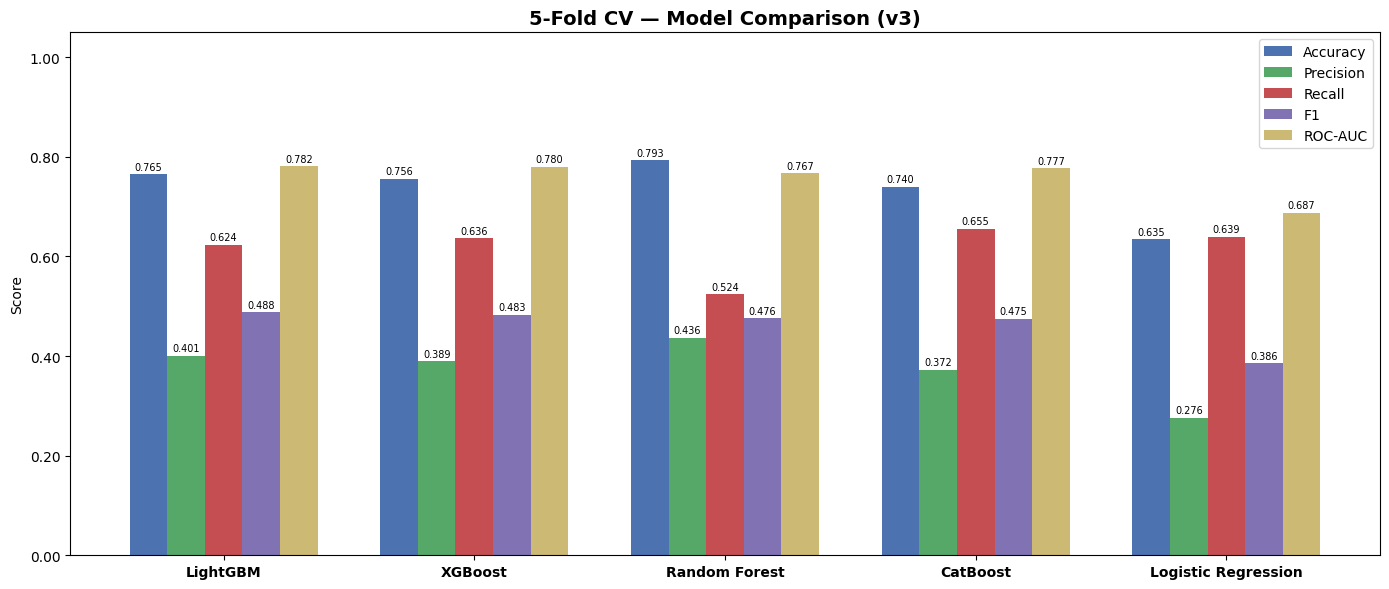

In [16]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(results_df))
width = 0.15
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"]

fig, ax = plt.subplots(figsize=(14, 6))
for idx, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (idx - len(metrics)/2 + 0.5) * width
    bars = ax.bar(x + offset, results_df[metric], width, label=metric, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("5-Fold CV — Model Comparison (v3)", fontweight="bold", fontsize=14)
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig(models_dir / "cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 11. Optuna Hyperparameter Tuning on Best Boosting Model

We tune the best boosting model from CV using Optuna with 30 trials. The objective maximizes **F1** via 3-fold CV (faster than 5-fold for tuning).

In [17]:
# Identify best boosting model from CV
# Ensure results_df exists (from cell 9 CV results)
import sklearn
if 'results_df' not in locals():
    print("⚠️  results_df not found. Running CV first...")
    # Re-run minimal CV to get results
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"f1": "f1", "accuracy": "accuracy", "precision": "precision", "recall": "recall", "roc_auc": "roc_auc"}
    all_results = []
    
    for name, model in sklearn_models.items():
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        cv_r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        all_results.append({
            "Model": name,
            "Accuracy": cv_r["test_accuracy"].mean(),
            "Precision": cv_r["test_precision"].mean(),
            "Recall": cv_r["test_recall"].mean(),
            "F1": cv_r["test_f1"].mean(),
            "ROC-AUC": cv_r["test_roc_auc"].mean(),
        })
    
    for name, model in [("LightGBM", lgbm_model), ("XGBoost", xgb_model), ("CatBoost", cat_model)]:
        cv_r = cross_validate(model, X_train_boost, y_train, cv=cv, scoring=scoring, n_jobs=1)
        all_results.append({
            "Model": name,
            "Accuracy": cv_r["test_accuracy"].mean(),
            "Precision": cv_r["test_precision"].mean(),
            "Recall": cv_r["test_recall"].mean(),
            "F1": cv_r["test_f1"].mean(),
            "ROC-AUC": cv_r["test_roc_auc"].mean(),
        })
    
    results_df = pd.DataFrame(all_results).sort_values("F1", ascending=False).reset_index(drop=True)

boost_models = results_df[results_df["Model"].isin(["LightGBM", "XGBoost", "CatBoost"])]
best_boost_name = boost_models.iloc[0]["Model"]
print(f"Tuning: {best_boost_name} (best boosting model from CV)")
print(f"Baseline CV F1: {boost_models.iloc[0]['F1']:.4f}")
print("\nRunning 30 Optuna trials (3-fold CV each)...\n")

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    if best_boost_name == "LightGBM":
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 500, 1500),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15),
            "num_leaves":       trial.suggest_int("num_leaves", 31, 255),
            "max_depth":        trial.suggest_int("max_depth", 5, 15),
            "min_child_samples":trial.suggest_int("min_child_samples", 10, 60),
            "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "is_unbalance":     True,
            "random_state":     RANDOM_STATE,
            "n_jobs":           -1,
            "verbose":          -1,
        }
        model = lgb.LGBMClassifier(**params)
    elif best_boost_name == "XGBoost":
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 500, 1500),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15),
            "max_depth":        trial.suggest_int("max_depth", 4, 12),
            "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "scale_pos_weight": spw,
            "eval_metric":      "logloss",
            "random_state":     RANDOM_STATE,
            "n_jobs":           -1,
            "verbosity":        0,
        }
        model = xgb.XGBClassifier(**params)
    else:  # CatBoost
        params = {
            "iterations":       trial.suggest_int("iterations", 500, 1500),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15),
            "depth":            trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg":      trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
            "auto_class_weights": "Balanced",
            "random_seed":      RANDOM_STATE,
            "verbose":          0,
        }
        model = CatBoostClassifier(**params)

    scores = cross_validate(model, X_train_boost, y_train, cv=cv_tune,
                            scoring="f1", n_jobs=1)
    return scores["test_score"].mean()


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n{'='*50}")
print(f"  Optuna Results — {best_boost_name}")
print(f"{'='*50}")
print(f"  Best CV F1     : {study.best_value:.4f}")
print(f"  Improvement    : {study.best_value - boost_models.iloc[0]['F1']:+.4f}")
print(f"  Best params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

Tuning: LightGBM (best boosting model from CV)
Baseline CV F1: 0.4880

Running 30 Optuna trials (3-fold CV each)...



Best trial: 22. Best value: 0.488135: 100%|██████████| 30/30 [1:17:13<00:00, 154.45s/it]


  Optuna Results — LightGBM
  Best CV F1     : 0.4881
  Improvement    : +0.0001
  Best params:
    n_estimators: 1394
    learning_rate: 0.023967319860051944
    num_leaves: 255
    max_depth: 15
    min_child_samples: 37
    subsample: 0.8623925036371677
    colsample_bytree: 0.624043375390297
    reg_alpha: 0.3056058157685999
    reg_lambda: 0.02770627219263383


### 12. Train Tuned Model + Threshold Optimization

Instead of using the default 0.5 threshold, we find the threshold that **maximizes F1** on the training set via cross-validated probabilities.

Finding optimal threshold via 5-fold cross-validated probabilities...

  Threshold Optimization Results
  Default threshold (0.50) F1 : 0.4922
  Optimal threshold          : 0.5552
  Optimized CV F1            : 0.4967
  Optimized CV Accuracy      : 0.8040
  Optimized CV Precision     : 0.4607
  Optimized CV Recall        : 0.5388


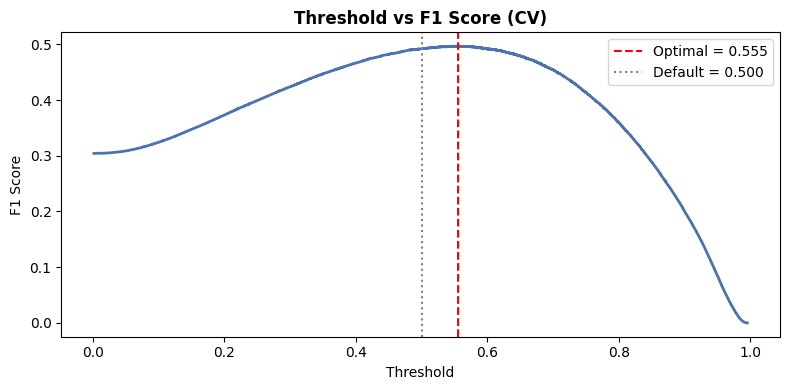

In [18]:
# ── Build tuned model ──
best_params = study.best_params.copy()

if best_boost_name == "LightGBM":
    best_params.update({"is_unbalance": True, "random_state": RANDOM_STATE,
                        "n_jobs": -1, "verbose": -1})
    tuned_model = lgb.LGBMClassifier(**best_params)
elif best_boost_name == "XGBoost":
    best_params.update({"scale_pos_weight": spw, "eval_metric": "logloss",
                        "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0})
    tuned_model = xgb.XGBClassifier(**best_params)
else:
    best_params.update({"auto_class_weights": "Balanced", "random_seed": RANDOM_STATE, "verbose": 0})
    tuned_model = CatBoostClassifier(**best_params)

# ── Get CV probabilities to find optimal threshold ──
print("Finding optimal threshold via 5-fold cross-validated probabilities...")
cv_probs = cross_val_predict(tuned_model, X_train_boost, y_train,
                              cv=cv, method="predict_proba", n_jobs=1)[:, 1]

# Sweep thresholds to maximize F1
precisions, recalls, thresholds = precision_recall_curve(y_train, cv_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_cv     = f1_scores[best_idx]

# Also check accuracy at this threshold
cv_preds_tuned = (cv_probs >= best_threshold).astype(int)
cv_acc_tuned   = accuracy_score(y_train, cv_preds_tuned)

print(f"\n{'='*50}")
print(f"  Threshold Optimization Results")
print(f"{'='*50}")
print(f"  Default threshold (0.50) F1 : {f1_score(y_train, (cv_probs >= 0.5).astype(int)):.4f}")
print(f"  Optimal threshold          : {best_threshold:.4f}")
print(f"  Optimized CV F1            : {best_f1_cv:.4f}")
print(f"  Optimized CV Accuracy      : {cv_acc_tuned:.4f}")
print(f"  Optimized CV Precision     : {precisions[best_idx]:.4f}")
print(f"  Optimized CV Recall        : {recalls[best_idx]:.4f}")

# ── Plot threshold vs F1 ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores[:-1], color="#4C72B0", lw=2)
ax.axvline(best_threshold, color="red", linestyle="--", label=f"Optimal = {best_threshold:.3f}")
ax.axvline(0.5, color="grey", linestyle=":", label="Default = 0.500")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("Threshold vs F1 Score (CV)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(models_dir / "threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

### 13. Train Final Tuned Model on Full Training Set

In [20]:
# Re-create fresh tuned model and train on ALL training data
if best_boost_name == "LightGBM":
    final_model = lgb.LGBMClassifier(**{**study.best_params,
        "is_unbalance": True, "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
elif best_boost_name == "XGBoost":
    final_model = xgb.XGBClassifier(**{**study.best_params,
        "scale_pos_weight": spw, "eval_metric": "logloss",
        "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0})
else:
    final_model = CatBoostClassifier(**{**study.best_params,
        "auto_class_weights": "Balanced", "random_seed": RANDOM_STATE, "verbose": 0})

final_model.fit(X_train_boost, y_train)

print(f"\u2705 {best_boost_name} (Optuna-tuned) trained on full training set.")
print(f"   Features used : {len(boost_feature_names)}")

✅ LightGBM (Optuna-tuned) trained on full training set.
   Features used : 39


### 14. Evaluate on Test Set (with Optimized Threshold)

In [21]:
y_prob = final_model.predict_proba(X_test_boost)[:, 1]

# ── Default threshold ──
y_pred_default = (y_prob >= 0.5).astype(int)

# ── Optimized threshold ──
y_pred = (y_prob >= best_threshold).astype(int)

print("=" * 55)
print(f"  {best_boost_name} (Tuned) — Test Set @ threshold={best_threshold:.3f}")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test,  y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test,    y_pred):.4f}")
print(f"  F1        : {f1_score(y_test,        y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test,   y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["On-Time", "Delayed"]))

# ── Comparison ──
print("\n--- Comparison ---")
print(f"  v2 LightGBM (default thresh=0.5)  : Acc=0.7316  F1=0.4627  AUC=0.7667")
print(f"  v3 {best_boost_name} (default thresh=0.5)  : Acc={accuracy_score(y_test, y_pred_default):.4f}  F1={f1_score(y_test, y_pred_default):.4f}  AUC={roc_auc_score(y_test, y_prob):.4f}")
print(f"  v3 {best_boost_name} (optimal thresh={best_threshold:.3f}): Acc={accuracy_score(y_test, y_pred):.4f}  F1={f1_score(y_test, y_pred):.4f}  AUC={roc_auc_score(y_test, y_prob):.4f}")

  LightGBM (Tuned) — Test Set @ threshold=0.555
  Accuracy  : 0.8001
  Precision : 0.4529
  Recall    : 0.5487
  F1        : 0.4962
  ROC-AUC   : 0.7820

              precision    recall  f1-score   support

     On-Time       0.90      0.86      0.88     80865
     Delayed       0.45      0.55      0.50     17687

    accuracy                           0.80     98552
   macro avg       0.67      0.70      0.69     98552
weighted avg       0.82      0.80      0.81     98552


--- Comparison ---
  v2 LightGBM (default thresh=0.5)  : Acc=0.7316  F1=0.4627  AUC=0.7667
  v3 LightGBM (default thresh=0.5)  : Acc=0.7719  F1=0.4904  AUC=0.7820
  v3 LightGBM (optimal thresh=0.555): Acc=0.8001  F1=0.4962  AUC=0.7820


### 15. Stacking Ensemble (LightGBM + XGBoost + CatBoost)

Combine the three boosting models via a Logistic Regression meta-learner. Each base model's cross-validated probabilities become features for the meta-model.

In [22]:
print("Building stacking ensemble...")
print("  Base models: LightGBM + XGBoost + CatBoost")
print("  Meta-learner: Logistic Regression")
print("  Method: 5-fold CV stacking\n")

# ── Train each base model and get CV probabilities ──
base_models = {
    "LightGBM": lgb.LGBMClassifier(
        **{**study.best_params, "is_unbalance": True,
           "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1}
    ) if best_boost_name == "LightGBM" else lgb.LGBMClassifier(
        n_estimators=800, learning_rate=0.05, num_leaves=127, max_depth=-1,
        min_child_samples=30, subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0, is_unbalance=True,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        **{**study.best_params, "scale_pos_weight": spw, "eval_metric": "logloss",
           "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0}
    ) if best_boost_name == "XGBoost" else xgb.XGBClassifier(
        n_estimators=800, learning_rate=0.05, max_depth=7, subsample=0.8,
        colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=spw, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    "CatBoost": CatBoostClassifier(
        **{**study.best_params, "auto_class_weights": "Balanced",
           "random_seed": RANDOM_STATE, "verbose": 0}
    ) if best_boost_name == "CatBoost" else CatBoostClassifier(
        iterations=800, learning_rate=0.05, depth=8, l2_leaf_reg=3.0,
        auto_class_weights="Balanced", random_seed=RANDOM_STATE, verbose=0
    ),
}

# Get CV probabilities for stacking
stack_train = np.zeros((len(y_train), len(base_models)))
stack_test  = np.zeros((len(y_test),  len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    print(f"  Stacking CV: {name}...", end=" ", flush=True)
    # CV predictions on train
    stack_train[:, i] = cross_val_predict(
        model, X_train_boost, y_train, cv=cv, method="predict_proba", n_jobs=1
    )[:, 1]
    # Train on full train, predict on test
    model.fit(X_train_boost, y_train)
    stack_test[:, i] = model.predict_proba(X_test_boost)[:, 1]
    print(f"done (CV F1={f1_score(y_train, (stack_train[:, i] >= 0.5).astype(int)):.4f})")

# ── Meta-learner ──
print("\n  Training meta-learner...")
meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
meta_model.fit(stack_train, y_train)

# ── Stacking predictions ──
stack_prob = meta_model.predict_proba(stack_test)[:, 1]

# ── Optimize stacking threshold too ──
stack_cv_prob = meta_model.predict_proba(stack_train)[:, 1]
p, r, t = precision_recall_curve(y_train, stack_cv_prob)
f1s = 2 * p * r / (p + r + 1e-8)
stack_threshold = t[np.argmax(f1s)]

stack_pred = (stack_prob >= stack_threshold).astype(int)

print(f"\n{'='*55}")
print(f"  Stacking Ensemble — Test Set @ threshold={stack_threshold:.3f}")
print(f"{'='*55}")
print(f"  Accuracy  : {accuracy_score(y_test,  stack_pred):.4f}")
print(f"  Precision : {precision_score(y_test, stack_pred):.4f}")
print(f"  Recall    : {recall_score(y_test,    stack_pred):.4f}")
print(f"  F1        : {f1_score(y_test,        stack_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test,   stack_prob):.4f}")
print()
print(classification_report(y_test, stack_pred, target_names=["On-Time", "Delayed"]))

Building stacking ensemble...
  Base models: LightGBM + XGBoost + CatBoost
  Meta-learner: Logistic Regression
  Method: 5-fold CV stacking

  Stacking CV: LightGBM... done (CV F1=0.4922)
  Stacking CV: XGBoost... done (CV F1=0.4830)
  Stacking CV: CatBoost... done (CV F1=0.4749)

  Training meta-learner...

  Stacking Ensemble — Test Set @ threshold=0.269
  Accuracy  : 0.7955
  Precision : 0.4447
  Recall    : 0.5611
  F1        : 0.4962
  ROC-AUC   : 0.7831

              precision    recall  f1-score   support

     On-Time       0.90      0.85      0.87     80865
     Delayed       0.44      0.56      0.50     17687

    accuracy                           0.80     98552
   macro avg       0.67      0.70      0.68     98552
weighted avg       0.82      0.80      0.80     98552



### 16. Pick Best Overall Model

In [23]:
# Compare all approaches on test set
approaches = {
    f"{best_boost_name} (tuned, thresh={best_threshold:.3f})": {
        "y_pred": y_pred, "y_prob": y_prob, "model": final_model, "threshold": best_threshold,
        "type": "single"
    },
    f"Stacking Ensemble (thresh={stack_threshold:.3f})": {
        "y_pred": stack_pred, "y_prob": stack_prob, "threshold": stack_threshold,
        "type": "stack"
    },
}

print("=" * 65)
print("  Final Test Set Comparison")
print("=" * 65)
print(f"{'Approach':<45} {'Acc':>6} {'F1':>6} {'AUC':>6}")
print("-" * 65)
print(f"{'v2 LightGBM (baseline, thresh=0.5)':<45} {'0.732':>6} {'0.463':>6} {'0.767':>6}")

best_approach_name = None
best_f1 = 0
for name, info in approaches.items():
    acc = accuracy_score(y_test, info["y_pred"])
    f1  = f1_score(y_test, info["y_pred"])
    auc = roc_auc_score(y_test, info["y_prob"])
    print(f"{name:<45} {acc:>6.3f} {f1:>6.3f} {auc:>6.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_approach_name = name

print("-" * 65)
print(f"\n\u2705 Best approach: {best_approach_name}")

# Decide which to save
best_info = approaches[best_approach_name]
use_stack = best_info["type"] == "stack"

if use_stack:
    print("   Using stacking ensemble as final model.")
    final_y_pred = stack_pred
    final_y_prob = stack_prob
    final_threshold = stack_threshold
else:
    print(f"   Using tuned {best_boost_name} as final model.")
    final_y_pred = y_pred
    final_y_prob = y_prob
    final_threshold = best_threshold

  Final Test Set Comparison
Approach                                         Acc     F1    AUC
-----------------------------------------------------------------
v2 LightGBM (baseline, thresh=0.5)             0.732  0.463  0.767
LightGBM (tuned, thresh=0.555)                 0.800  0.496  0.782
Stacking Ensemble (thresh=0.269)               0.795  0.496  0.783
-----------------------------------------------------------------

✅ Best approach: LightGBM (tuned, thresh=0.555)
   Using tuned LightGBM as final model.


### 17. Confusion Matrix

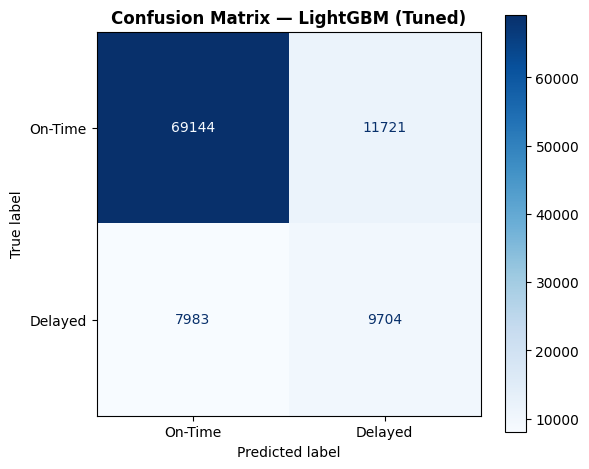

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, final_y_pred,
    display_labels=["On-Time", "Delayed"],
    cmap="Blues", ax=ax
)
title = "Confusion Matrix — Stacking Ensemble" if use_stack else f"Confusion Matrix — {best_boost_name} (Tuned)"
ax.set_title(title, fontweight="bold")
plt.tight_layout()
plt.savefig(models_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 18. ROC Curve

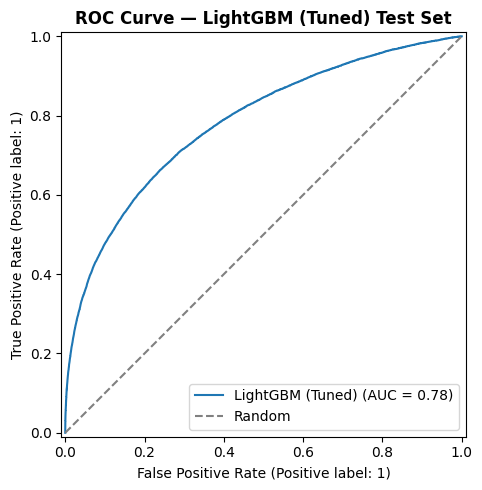

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
label = "Stacking" if use_stack else f"{best_boost_name} (Tuned)"
RocCurveDisplay.from_predictions(y_test, final_y_prob, ax=ax, name=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
ax.set_title(f"ROC Curve — {label} Test Set", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(models_dir / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 19. Feature Importance (Top 25)

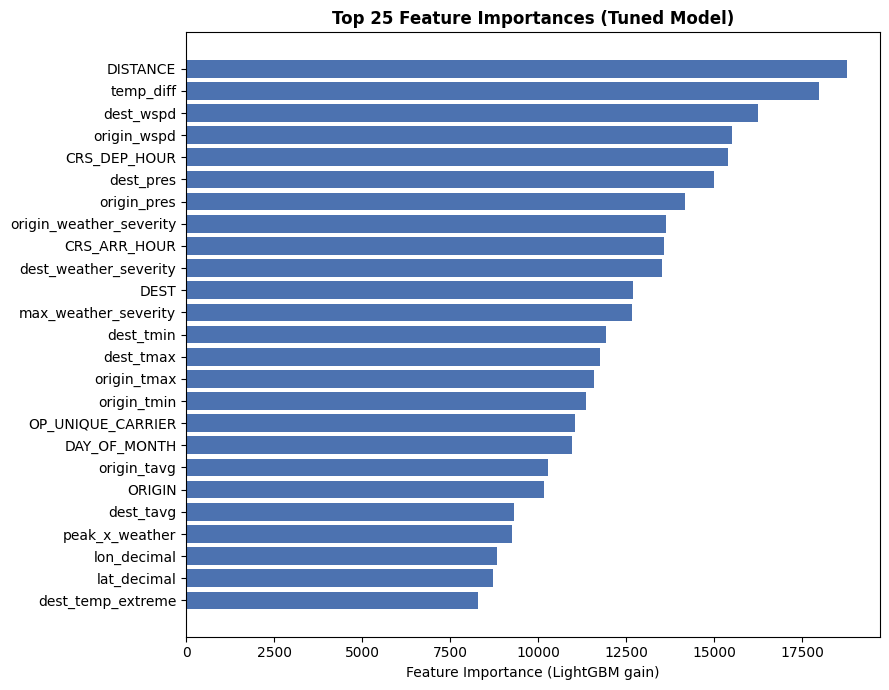


Top 10 features:
                feature  importance
               DISTANCE       18769
              temp_diff       17961
              dest_wspd       16239
            origin_wspd       15515
           CRS_DEP_HOUR       15390
              dest_pres       15004
            origin_pres       14157
origin_weather_severity       13630
           CRS_ARR_HOUR       13571
  dest_weather_severity       13509


In [26]:
# Use the single tuned model for feature importance (even if stack won)
importance_df = pd.DataFrame({
    "feature"   : boost_feature_names,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#4C72B0")
ax.set_xlabel(f"Feature Importance ({best_boost_name} gain)")
ax.set_title("Top 25 Feature Importances (Tuned Model)", fontweight="bold")
plt.tight_layout()
plt.savefig(models_dir / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

### 20. Save All Artifacts

In [27]:
# Save tuned single model (always — used for SHAP explainability)
joblib.dump(final_model, models_dir / "airline_delay_lgbm.pkl")

# Save stacking components if stacking was best
if use_stack:
    joblib.dump(base_models, models_dir / "stack_base_models.pkl")
    joblib.dump(meta_model,  models_dir / "stack_meta_model.pkl")

# Save feature names, test arrays, threshold
joblib.dump(boost_feature_names, models_dir / "feature_names.pkl")
joblib.dump(final_threshold,     models_dir / "optimal_threshold.pkl")
np.save(models_dir / "X_test_boost.npy", X_test_boost)

# Save CV results table
results_df.to_csv(models_dir / "cv_results.csv", index=False)

# Save Optuna best params
joblib.dump(study.best_params, models_dir / "optuna_best_params.pkl")

# Save encoders for deployment
joblib.dump(ord_enc, models_dir / "ordinal_encoder.pkl")
joblib.dump(num_imp, models_dir / "numeric_imputer.pkl")

print("\u2705 All artifacts saved:")
print(f"  models/airline_delay_lgbm.pkl       — tuned {best_boost_name} model")
if use_stack:
    print(f"  models/stack_base_models.pkl        — stacking base models")
    print(f"  models/stack_meta_model.pkl         — stacking meta-learner")
print(f"  models/feature_names.pkl            — feature name list")
print(f"  models/optimal_threshold.pkl        — threshold = {final_threshold:.4f}")
print(f"  models/X_test_boost.npy             — preprocessed test array")
print(f"  models/cv_results.csv               — CV results table")
print(f"  models/optuna_best_params.pkl       — Optuna best hyperparameters")
print(f"  models/ordinal_encoder.pkl          — fitted OrdinalEncoder")
print(f"  models/numeric_imputer.pkl          — fitted SimpleImputer")
print(f"  models/cv_comparison.png            — CV bar chart")
print(f"  models/threshold_optimization.png   — threshold vs F1 plot")
print(f"  models/confusion_matrix.png         — confusion matrix")
print(f"  models/roc_curve.png                — ROC curve")
print(f"  models/feature_importance.png        — feature importances")

✅ All artifacts saved:
  models/airline_delay_lgbm.pkl       — tuned LightGBM model
  models/feature_names.pkl            — feature name list
  models/optimal_threshold.pkl        — threshold = 0.5552
  models/X_test_boost.npy             — preprocessed test array
  models/cv_results.csv               — CV results table
  models/optuna_best_params.pkl       — Optuna best hyperparameters
  models/ordinal_encoder.pkl          — fitted OrdinalEncoder
  models/numeric_imputer.pkl          — fitted SimpleImputer
  models/cv_comparison.png            — CV bar chart
  models/threshold_optimization.png   — threshold vs F1 plot
  models/confusion_matrix.png         — confusion matrix
  models/roc_curve.png                — ROC curve
  models/feature_importance.png        — feature importances
